In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
sns.set_palette('Set2')

df = pd.read_csv("C:/Data Analyst Projects/04_Supply_Chain_Logistics_Analytics/supply_chain_data.csv")

print("Data Shape:", df.shape)
df.head()

Data Shape: (100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [4]:
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
df.describe().T


--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Price,100.0,49.462461,31.168193,1.699976,19.597823,51.239831,77.198228,99.171329
Availability,100.0,48.400000,30.743317,1.000000,22.750000,43.500000,75.000000,100.000000
Number of products sold,100.0,460.990000,303.780074,8.000000,184.250000,392.500000,704.250000,996.000000
Revenue generated,100.0,5776.048187,2732.841744,1061.618523,2812.847151,6006.352023,8253.976921,9866.465458
Stock levels,100.0,47.770000,31.369372,0.000000,16.750000,47.500000,73.000000,100.000000
Lead times,100.0,15.960000,8.785801,1.000000,8.000000,17.000000,24.000000,30.000000
Order quantities,100.0,49.220000,26.784429,1.000000,26.000000,52.000000,71.250000,96.000000
Shipping times,100.0,5.750000,2.724283,1.000000,3.750000,6.000000,8.000000,10.000000
Shipping costs,100.0,5.548149,2.651376,1.013487,3.540248,5.320534,7.601695,9.929816
Lead time,100.0,17.080000,8.846251,1.000000,10.000000,18.000000,25.000000,30.000000


In [9]:
df['Total_Logistics_Cost'] = df['Manufacturing costs'] + df['Shipping costs'] + df['Costs']

df['Net_Profit'] = df['Revenue generated'] - df['Total_Logistics_Cost']

df['Profit_Margin_%'] = (df['Net_Profit'] / df['Revenue generated']) * 100

def classify_stock(stock):
    if stock < 20:
        return 'Critical Reorder Required'
    elif stock <= 50:
        return 'Low Stock Alert'
    else:
        return 'Sufficient Stock'

df['Stock_Status'] = df['Stock levels'].apply(classify_stock)

df[['SKU', 'Stock levels', 'Stock_Status', 'Revenue generated', 'Net_Profit', 'Profit_Margin_%']].head()

,SKU,Stock levels,Stock_Status,Revenue generated,Net_Profit,Profit_Margin_%
0,SKU0,58,Sufficient Stock,8661.996792,8425.008266,97.264043
1,SKU1,53,Sufficient Stock,7460.900065,6914.501143,92.676501
2,SKU2,1,Critical Reorder Required,9577.749626,9397.086845,98.113724
3,SKU3,23,Low Stock Alert,7766.836426,7474.705957,96.238746
4,SKU4,5,Critical Reorder Required,2686.505152,1667.108811,62.054927


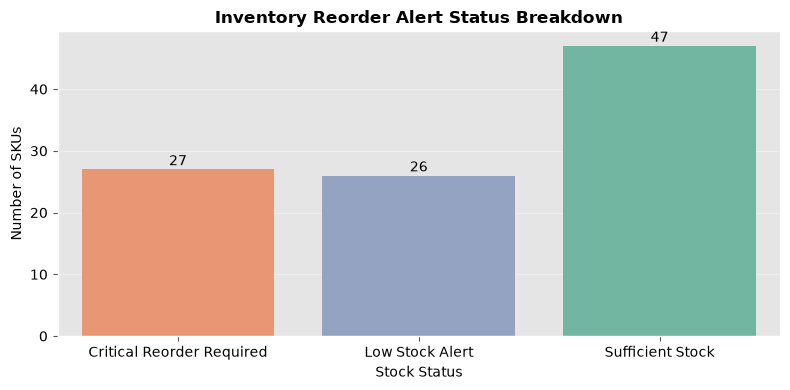

In [16]:
plt.figure(figsize=(8, 4))
plt.style.use('ggplot')

ax1 = sns.countplot(
    data=df,
    x='Stock_Status',
    hue='Stock_Status',
    dodge=False,
    order=['Critical Reorder Required', 'Low Stock Alert', 'Sufficient Stock'],
    palette='Set2'
)

if ax1.get_legend() is not None:
    ax1.get_legend().remove()

plt.title('Inventory Reorder Alert Status Breakdown', color='black', fontsize=12, fontweight='bold')
plt.xlabel('Stock Status', color='black', fontsize=10)
plt.ylabel('Number of SKUs', color='black', fontsize=10)
plt.xticks(color='black')
plt.yticks(color='black')

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

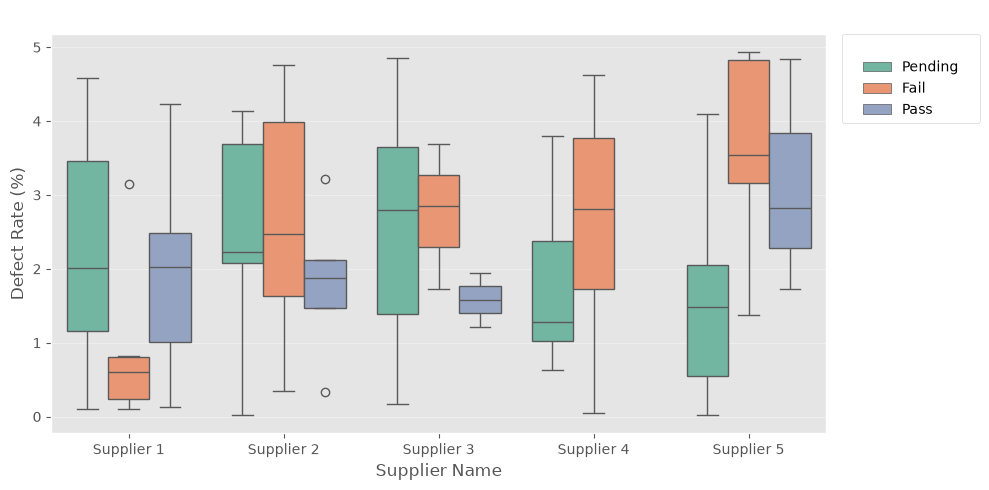

In [26]:
plt.figure(figsize=(10, 5))

supplier_order = ['Supplier 1', 'Supplier 2', 'Supplier 3', 'Supplier 4', 'Supplier 5']

ax2 = sns.boxplot(
    data=df,
    x='Supplier name',
    y='Defect rates',
    hue='Inspection results',
    order=supplier_order,
    palette='Set2'
)

ax2.set(
    title='Supplier Defect Rates & Inspection Performance',
    xlabel='Supplier Name',
    ylabel='Defect Rate (%)'
)

plt.legend(
    title='Inspection Results',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    facecolor='white',
    labelcolor='black',
    frameon=True
)

plt.tight_layout()
plt.show()

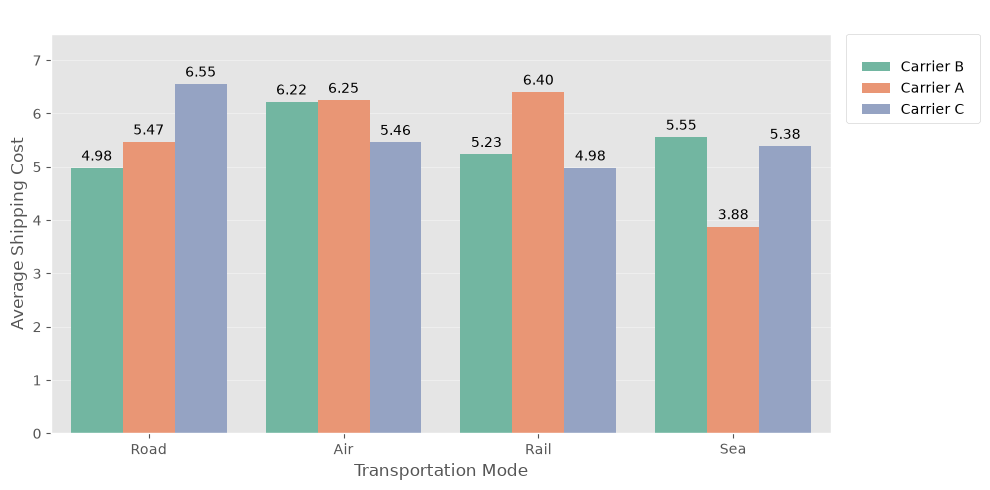

In [27]:
plt.figure(figsize=(10, 5))

ax3 = sns.barplot(
    data=df,
    x='Transportation modes',
    y='Shipping costs',
    hue='Shipping carriers',
    errorbar=None,
    palette='Set2'
)

ax3.set(
    title='Average Shipping Cost by Carrier & Mode of Transport',
    xlabel='Transportation Mode',
    ylabel='Average Shipping Cost'
)

plt.ylim(0, 7.5)

for container in ax3.containers:
    ax3.bar_label(container, fmt='%.2f', label_type='edge', padding=3, color='black')


plt.legend(
    title='Shipping Carriers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    facecolor='white',
    labelcolor='black',
    frameon=True
)

plt.tight_layout()
plt.show()

In [29]:
total_skus = df['SKU'].nunique()
total_stock = df['Stock levels'].sum()
avg_defect_rate = df['Defect rates'].mean()
total_shipping_cost = df['Shipping costs'].sum()

critical_stock_count = (df['Stock levels'] < 20).sum()

print("="*45)
print("          PROJECT KEY PERFORMANCE INDICATORS        ")
print("="*45)
print(f"1. Total Active SKUs/Products : {total_skus}")
print(f"2. Total Inventory Stock      : {total_stock:,} units")
print(f"3. Overall Avg Defect Rate    : {avg_defect_rate:.2f}%")
print(f"4. Total Logistics/Ship Cost  : ${total_shipping_cost:,.2f}")
print(f"5. Critical Stock Items (<20) : {critical_stock_count} SKUs")
print("="*45)

          PROJECT KEY PERFORMANCE INDICATORS        
1. Total Active SKUs/Products : 100
2. Total Inventory Stock      : 4,777 units
3. Overall Avg Defect Rate    : 2.28%
4. Total Logistics/Ship Cost  : $554.81
5. Critical Stock Items (<20) : 27 SKUs


In [31]:
df.to_csv('cleaned_supply_chain_data.csv', index=False)
print("Cleaned CSV successfully re-exported without index!")

Cleaned CSV successfully re-exported without index!
